# Data Project: More data prep and then analyses

## The Goal

You already have:
- completed the Final Project Data Prep
- a research question (that may need some refining)
- variables (that may need some subsetting or collapsing)

Now your tasks are to:

- Make sure your data is ready and your question is answerable.
- Learn a few new data prep techniques
- Learn a couple more hypothesis tests


For this notebook, I will use the Two Year College Scorecard dataset to do some examples of data prep and analysis that you may need for your project.  You should use parts of the code from this notebook that is appropriate for your project. <b>That is, add on to your data prep notebook</b>
                                                                                                                                                                                                                                
                                                                                                                                                    


# ---

## Part 1: Load & Preview Your Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
link = "https://raw.githubusercontent.com/humdskyline/data/main/CollegeScores2year.csv"
df = pd.read_csv(link)

# Preview the first few rows
df.head()

,Name,State,ID,Main,Accred,MainDegree,HighDegree,Control,Region,Locale,...,TuitionFTE,InstructFTE,FacSalary,FullTimeFac,Pell,CompRate,Debt,Female,FirstGen,MedIncome
0,Central Alabama Community College,AL,100760,1,Southern Association of Colleges and Schools C...,2,2,Public,Southeast,Town,...,1580.0,6738.0,5896.0,44.9,47.9,27.84,191.0,60.4,55.0,22.2
1,Chattahoochee Valley Community College,AL,101028,1,Southern Association of Colleges and Schools C...,2,2,Public,Southeast,Rural,...,2035.0,4467.0,5961.0,38.3,53.8,19.58,161.0,61.2,43.0,20.8
2,Enterprise State Community College,AL,101143,1,Southern Association of Colleges and Schools C...,2,2,Public,Southeast,Town,...,2606.0,6309.0,6337.0,45.0,41.2,19.30,72.0,51.7,42.2,20.5
3,Coastal Alabama Community College,AL,101161,1,Southern Association of Colleges and Schools C...,2,2,Public,Southeast,Town,...,1949.0,4029.0,5932.0,47.4,40.1,14.32,468.0,65.3,43.5,24.2
4,George C Wallace Community College-Dothan,AL,101286,1,Southern Association of Colleges and Schools C...,2,2,Public,Southeast,City,...,2313.0,5319.0,5866.0,58.5,51.1,23.74,NaN,66.8,48.5,15.8


In [3]:
# How many rows and columns are in the dataset?
df.shape

(1141, 37)

In [4]:
# What are the column names?
df.columns

Index(['Name', 'State', 'ID', 'Main', 'Accred', 'MainDegree', 'HighDegree',
       'Control', 'Region', 'Locale', 'Latitude', 'Longitude', 'AdmitRate',
       'MidACT', 'AvgSAT', 'Online', 'Enrollment', 'White', 'Black',
       'Hispanic', 'Asian', 'Other', 'PartTime', 'NetPrice', 'Cost',
       'TuitionIn', 'TuitonOut', 'TuitionFTE', 'InstructFTE', 'FacSalary',
       'FullTimeFac', 'Pell', 'CompRate', 'Debt', 'Female', 'FirstGen',
       'MedIncome'],
      dtype='object')

In [5]:
# What data types does Python think each column has?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1141 entries, 0 to 1140
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         1141 non-null   object 
 1   State        1141 non-null   object 
 2   ID           1141 non-null   int64  
 3   Main         1141 non-null   int64  
 4   Accred       1140 non-null   object 
 5   MainDegree   1141 non-null   int64  
 6   HighDegree   1141 non-null   int64  
 7   Control      1141 non-null   object 
 8   Region       1141 non-null   object 
 9   Locale       1138 non-null   object 
 10  Latitude     1141 non-null   float64
 11  Longitude    1141 non-null   float64
 12  AdmitRate    144 non-null    float64
 13  MidACT       31 non-null     float64
 14  AvgSAT       33 non-null     float64
 15  Online       1141 non-null   int64  
 16  Enrollment   1141 non-null   int64  
 17  White        1141 non-null   float64
 18  Black        1141 non-null   float64
 19  Hispan

### Subset your data

This is like .where() in the DataScience module

In [6]:
# I only want colleges from California
ca_df = df[df["State"] == "CA"]
ca_df

,Name,State,ID,Main,Accred,MainDegree,HighDegree,Control,Region,Locale,...,TuitionFTE,InstructFTE,FacSalary,FullTimeFac,Pell,CompRate,Debt,Female,FirstGen,MedIncome
30,Allan Hancock College,CA,108807,1,Western Association of Schools and Colleges Ac...,2,2,Public,West,City,...,654.0,5767.0,6756.0,27.7,21.0,31.43,42.0,53.7,59.5,23.5
31,American Academy of Dramatic Arts-Los Angeles,CA,108852,0,Middle States Commission on Higher Education,2,2,Private,West,City,...,25137.0,8469.0,8120.0,16.0,30.0,69.18,232.0,59.5,23.4,41.2
32,Antelope Valley College,CA,109350,1,Western Association of Schools and Colleges Ac...,2,2,Public,West,Suburb,...,467.0,4683.0,8781.0,20.3,45.6,23.81,479.0,58.9,56.2,13.7
33,Bakersfield College,CA,109819,1,Western Association of Schools and Colleges Ac...,2,2,Public,West,City,...,536.0,4748.0,9433.0,54.0,34.2,22.77,67.0,58.4,63.1,18.2
34,Barstow Community College,CA,109907,1,Western Association of Schools and Colleges Ac...,2,2,Public,West,Town,...,399.0,3501.0,8516.0,27.6,49.6,15.58,NaN,62.8,53.1,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,International Sports Sciences Association,CA,485519,1,Distance Education Accrediting Commission,2,2,Profit,West,Suburb,...,8549.0,2651.0,5000.0,5.9,24.8,29.41,35.0,37.8,47.1,29.7
1118,Theatre of Arts,CA,486123,1,National Association of Schools of Theatre,2,2,Profit,West,City,...,13355.0,4475.0,NaN,NaN,68.1,NaN,16.0,31.1,NaN,13.4
1132,Clovis Community College,CA,489201,1,Western Association of Schools and Colleges Ac...,2,2,Public,West,City,...,568.0,3785.0,8696.0,29.8,13.9,NaN,NaN,62.6,41.7,20.0
1137,Platt College-Anaheim,CA,490878,0,Accrediting Commission of Career Schools and C...,2,0,Profit,West,City,...,1604.0,1089.0,4911.0,18.2,64.3,NaN,1413.0,NaN,NaN,NaN


In [7]:
#check for nulls
ca_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 30 to 1138
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         132 non-null    object 
 1   State        132 non-null    object 
 2   ID           132 non-null    int64  
 3   Main         132 non-null    int64  
 4   Accred       132 non-null    object 
 5   MainDegree   132 non-null    int64  
 6   HighDegree   132 non-null    int64  
 7   Control      132 non-null    object 
 8   Region       132 non-null    object 
 9   Locale       132 non-null    object 
 10  Latitude     132 non-null    float64
 11  Longitude    132 non-null    float64
 12  AdmitRate    11 non-null     float64
 13  MidACT       0 non-null      float64
 14  AvgSAT       1 non-null      float64
 15  Online       132 non-null    int64  
 16  Enrollment   132 non-null    int64  
 17  White        132 non-null    float64
 18  Black        132 non-null    float64
 19  Hispanic   

### Before dropping nulls, only get the columns that you are considering using for your project

In [8]:
ca_proj_df = ca_df[["Name", "MainDegree", "Enrollment", "Control", "Cost", "TuitionIn", "Pell", "MedIncome", "FirstGen", "CompRate", "Locale"]]
ca_proj_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 30 to 1138
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        132 non-null    object 
 1   MainDegree  132 non-null    int64  
 2   Enrollment  132 non-null    int64  
 3   Control     132 non-null    object 
 4   Cost        126 non-null    float64
 5   TuitionIn   129 non-null    float64
 6   Pell        131 non-null    float64
 7   MedIncome   130 non-null    float64
 8   FirstGen    123 non-null    float64
 9   CompRate    123 non-null    float64
 10  Locale      132 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage: 12.4+ KB


In [9]:
#Now is the time to drop the nulls
ca_proj_df = ca_proj_df.dropna()
ca_proj_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 30 to 1114
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        117 non-null    object 
 1   MainDegree  117 non-null    int64  
 2   Enrollment  117 non-null    int64  
 3   Control     117 non-null    object 
 4   Cost        117 non-null    float64
 5   TuitionIn   117 non-null    float64
 6   Pell        117 non-null    float64
 7   MedIncome   117 non-null    float64
 8   FirstGen    117 non-null    float64
 9   CompRate    117 non-null    float64
 10  Locale      117 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage: 11.0+ KB


In [10]:
ca_proj_df.describe()

,MainDegree,Enrollment,Cost,TuitionIn,Pell,MedIncome,FirstGen,CompRate
count,117.0,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,2.0,8812.726496,16104.948718,6106.256410,32.995726,19.177778,53.285470,34.714530
std,0.0,7003.420317,8423.356703,10679.064577,16.625740,6.381872,8.152715,17.468267
min,2.0,66.000000,8127.000000,1104.000000,7.300000,0.000000,23.400000,0.000000
25%,2.0,2891.000000,11442.000000,1150.000000,21.000000,16.400000,48.800000,23.940000
50%,2.0,7922.000000,13535.000000,1312.000000,29.400000,18.500000,54.200000,29.140000
75%,2.0,13213.000000,16171.000000,1426.000000,39.900000,20.600000,58.000000,38.490000
max,2.0,27190.000000,48893.000000,38645.000000,88.500000,44.600000,69.900000,90.320000


In [11]:
#what are those super expensive 2 year colleges in CA???
pricey_ca_df = ca_proj_df[ca_proj_df["Cost"] > 16000]
pricey_ca_df

,Name,MainDegree,Enrollment,Control,Cost,TuitionIn,Pell,MedIncome,FirstGen,CompRate,Locale
31,American Academy of Dramatic Arts-Los Angeles,2,280,Private,48240.0,34170.0,30.0,41.2,23.4,69.18,City
51,Crafton Hills College,2,5373,Public,19525.0,1143.0,16.6,20.5,56.8,29.14,Rural
59,Evergreen Valley College,2,7780,Public,17876.0,1356.0,27.7,15.2,63.7,32.37,City
60,FIDM-Fashion Institute of Design & Merchandisi...,2,2367,Profit,48893.0,32293.0,28.7,44.6,30.2,74.23,City
61,FIDM-Fashion Institute of Design & Merchandisi...,2,279,Profit,46244.0,32293.0,30.4,44.6,30.2,71.64,City
62,FIDM-Fashion Institute of Design & Merchandisi...,2,71,Profit,42591.0,32293.0,39.6,44.6,30.2,69.41,City
63,Feather River Community College District,2,1346,Public,16299.0,1461.0,16.8,24.2,48.4,35.50,Rural
69,Hartnell College,2,11218,Public,16171.0,1420.0,21.1,24.4,64.8,31.09,City
83,College of Marin,2,4190,Public,17803.0,1490.0,12.9,15.5,46.4,29.56,Suburb
92,Napa Valley College,2,5237,Public,17453.0,1142.0,20.7,22.2,51.1,33.65,City


## Collapsing variables
Let's say that I want to distinguish between high priced (>$16000) and not high priced colleges and make that a new column with values high and low

In [26]:
ca_proj_df['CostLevel'] = np.where(
                                    ca_proj_df['Cost'] > 16000,
                                    'high',
                                    'low'
                                )

ca_proj_df

,Name,MainDegree,Enrollment,Control,Cost,TuitionIn,Pell,MedIncome,FirstGen,CompRate,Locale,CostLevel
30,Allan Hancock College,2,9282,Public,10348.0,1352.0,21.0,23.5,59.5,31.43,City,low
31,American Academy of Dramatic Arts-Los Angeles,2,280,Private,48240.0,34170.0,30.0,41.2,23.4,69.18,City,high
32,Antelope Valley College,2,11868,Public,15110.0,1124.0,45.6,13.7,56.2,23.81,Suburb,low
33,Bakersfield College,2,18695,Public,12027.0,1325.0,34.2,18.2,63.1,22.77,City,low
34,Barstow Community College,2,2762,Public,14307.0,1104.0,49.6,15.0,53.1,15.58,Town,low
...,...,...,...,...,...,...,...,...,...,...,...,...
1059,Woodland Community College,2,2891,Public,11822.0,1124.0,28.5,16.7,58.4,21.29,Suburb,low
1069,Moreno Valley College,2,8087,Public,12434.0,1426.0,27.1,17.7,57.8,17.06,Suburb,low
1070,Norco College,2,8647,Public,11429.0,1420.0,22.7,20.4,54.2,24.30,Suburb,low
1083,Carrington College-Pomona,2,229,Profit,20423.0,33126.0,62.1,18.0,55.2,47.06,Suburb,high


## ANOVA (Analysis of Variance) 
For seeing if there is a difference in numerical data between groups.

- H0: All the means are the same
- H1: At least one of the means is different

I want to know if the completion rate is different by the Control type.

So the first thing I will look at are the numerical summaries for thatavg_comprate = df.groupby('Control')['comprate'].mean().reset_index()

In [13]:
avg_comprate = ca_proj_df.groupby('Control')['CompRate'].mean().reset_index()
avg_comprate

,Control,CompRate
0,Private,54.260000
1,Profit,62.585263
2,Public,27.969677


In [14]:
std_comprate = ca_proj_df.groupby('Control')['CompRate'].std().reset_index()
std_comprate

,Control,CompRate
0,Private,36.490163
1,Profit,13.277506
2,Public,8.073802


Make a graph to visualize this difference
For ANOVA, side-by-side boxplots are appropriate

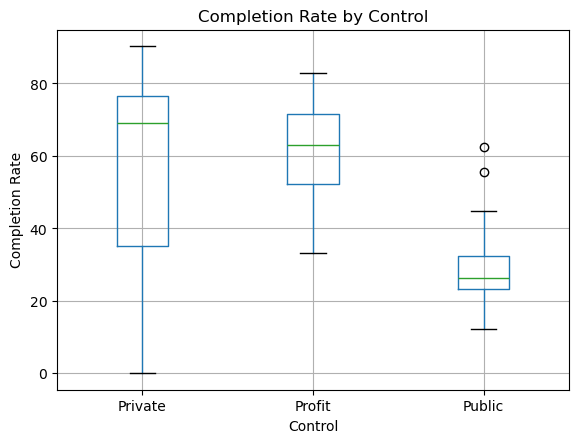

In [15]:
ca_proj_df.boxplot(column='CompRate', by='Control')

plt.title('Completion Rate by Control')
plt.suptitle('')   # removes automatic extra title
plt.xlabel('Control')
plt.ylabel('Completion Rate')

plt.show()

What do you notice from looking at the numerical summaries together with the side-by-side boxplots?  Write two sentences below with your description.

Now, here's the code for running an ANOVA

In [16]:
from scipy.stats import f_oneway

public = ca_proj_df[ca_proj_df['Control'] == 'Public']['CompRate']
private = ca_proj_df[ca_proj_df['Control'] == 'Private']['CompRate']
profit = ca_proj_df[ca_proj_df['Control'] == 'Profit']['CompRate']

f_stat, p_value = f_oneway(public, private, profit)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 82.17735735907596
p-value: 7.969982526171379e-23


Go back and look at your hypothesis testing notes.  What is the decision based on the p-value?  Write a sentence that includes the p-value, your decision, and reason.

Write out your conclusion to the hypothesis test.  If there is a difference discuss that as well.

## Chi-Square Test of Independence 
For seeing if there is an association between two groups.

** Before starting, you need to decide which variable you wish to compare across.  This is like the top row of a pivot table

- H0: <var 1> and <var 2> are independent
- H1: <var 1> and <var 2> are associated

This isn't particularly interesting, but my dataset has few categorical variables.  So for the sake of this example, I want to see if there is an association between Control and Locale.  That is, I want to see if by locale, there are the same percentages of public, private, and for profit colleges

In [17]:
loc_cont_df = ca_proj_df.pivot_table(
                            index='Control',
                            columns='Locale',
                            aggfunc='size'
                        )
loc_cont_df

Locale,City,Rural,Suburb,Town
Control,,,,
Private,4.0,NaN,1.0,NaN
Profit,14.0,1.0,4.0,NaN
Public,38.0,12.0,38.0,5.0


## Bad practice, but I want to get you some working code
I can't have any null values in my pivot table.  So I am going to get rid of the rural and towns and just look at cities and suburbs for this example

In [18]:
ca_cit_sub_df = ca_proj_df[(ca_proj_df["Locale"] == "City") | (ca_proj_df["Locale"] == "Suburb")]
ca_cit_sub_df

,Name,MainDegree,Enrollment,Control,Cost,TuitionIn,Pell,MedIncome,FirstGen,CompRate,Locale,CostLevel
30,Allan Hancock College,2,9282,Public,10348.0,1352.0,21.0,23.5,59.5,31.43,City,low
31,American Academy of Dramatic Arts-Los Angeles,2,280,Private,48240.0,34170.0,30.0,41.2,23.4,69.18,City,high
32,Antelope Valley College,2,11868,Public,15110.0,1124.0,45.6,13.7,56.2,23.81,Suburb,low
33,Bakersfield College,2,18695,Public,12027.0,1325.0,34.2,18.2,63.1,22.77,City,low
37,Cabrillo College,2,10556,Public,14270.0,1268.0,22.0,19.2,50.8,25.72,Suburb,low
...,...,...,...,...,...,...,...,...,...,...,...,...
1059,Woodland Community College,2,2891,Public,11822.0,1124.0,28.5,16.7,58.4,21.29,Suburb,low
1069,Moreno Valley College,2,8087,Public,12434.0,1426.0,27.1,17.7,57.8,17.06,Suburb,low
1070,Norco College,2,8647,Public,11429.0,1420.0,22.7,20.4,54.2,24.30,Suburb,low
1083,Carrington College-Pomona,2,229,Profit,20423.0,33126.0,62.1,18.0,55.2,47.06,Suburb,high


In [19]:
new_loc_cont_df = ca_cit_sub_df.pivot_table(
                            index='Control',
                            columns='Locale',
                            aggfunc='size'
                        )
new_loc_cont_df

Locale,City,Suburb
Control,,
Private,4,1
Profit,14,4
Public,38,38


## Technically, for a chi-square test, counts inside each cell need to be at least 5

For the sake of this example, let's just assume it meets the criteria.  We shall now display the pivot table with column percentages (proportions).  This is helpful to see if the relationship appears independent or not

In [20]:
col_proportions = new_loc_cont_df.div(new_loc_cont_df.sum(axis=0), axis= 1)
col_proportions = col_proportions.round(3)
col_proportions

Locale,City,Suburb
Control,,
Private,0.071,0.023
Profit,0.250,0.093
Public,0.679,0.884


Let's make a mosaic plot to get a visual of what's going on in this contingency table

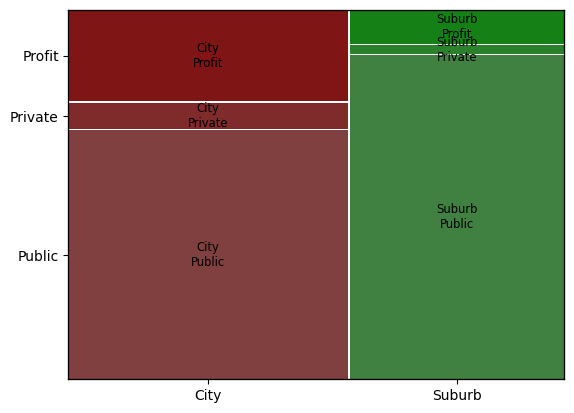

In [21]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

mosaic(ca_cit_sub_df, ['Locale', 'Control'])

plt.show()

What do you notice from looking at the pivot table together with the mosaic plot?  Write two sentences below with your description.

Now we are ready to perform the chi-square test of independence

In [22]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(new_loc_cont_df)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 5.747591362126246
p-value: 0.056484123457891985
Degrees of freedom: 2


In [23]:
expected_df = pd.DataFrame(
    expected,
    index=new_loc_cont_df.index,
    columns=new_loc_cont_df.columns
)

expected_df

Locale,City,Suburb
Control,,
Private,2.828283,2.171717
Profit,10.181818,7.818182
Public,42.989899,33.010101


Go back and look at your hypothesis testing notes.  What is the decision based on the p-value?  Write a sentence that includes the p-value, your decision, and reason.

Write out your conclusion to the hypothesis test. If there is a difference discuss that as well

## Correlation and Linear Regression 
For seeing if there is a linear association between two numerical variables and building a predictive model.

** Before starting, you need to decide which variable is your predictor variable. You also need to make a scatterplot to see if the relationship is linear or not.

- H0: <var 1> and <var 2> are NOT linearly correlated
- H1: <var 1> and <var 2> are linearly correlated

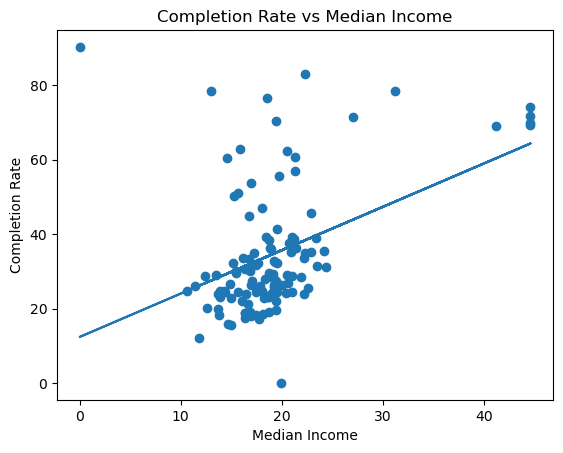

In [24]:

x = ca_proj_df['MedIncome']
y = ca_proj_df['CompRate']

plt.scatter(x, y)

# Best fit line
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

plt.xlabel('Median Income')
plt.ylabel('Completion Rate')
plt.title('Completion Rate vs Median Income')

plt.show()

Describe the strength, shape, and direction of the relationship

And now for the hypothesis test for correlation and the linear regression equation

Notice how nicely (and short) the code is using SciPy's built-in functionality

In [25]:
from scipy.stats import linregress

result = linregress(
    ca_proj_df['MedIncome'],
    ca_proj_df['CompRate']
)

print("Correlation (r):", result.rvalue)
print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("p-value:", result.pvalue)

Correlation (r): 0.4261129470888757
Slope: 1.166343425287757
Intercept: 12.346654891789154
p-value: 1.6676631135017673e-06


Go back and look at your hypothesis testing notes.  What is the decision based on the p-value?  Write a sentence that includes the p-value, your decision, and reason.

Write out your conclusion to the hypothesis test. Also, state the equation of your regression line

Use your regression line and equation to make a few predictions.  Write out what they mean in complete sentences